# The method of analogues on the Lorenz system

The engine is not specific to finance: it forecasts any target from any causal embedding. Lorenz
(1969) proposed forecasting by analogues for exactly this kind of chaotic system. We observe one
noisy coordinate, build a delay embedding (Takens), and forecast it `h` steps ahead.

In [1]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3df", "font.size": 9})
BLUE, ORANGE, AQUA, INK2 = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"

In [2]:
import numpy as np
from analogue_risk import Analogue

def lorenz(n, dt=0.01, s=10.0, r=28.0, b=8 / 3, seed=0):
    rng = np.random.default_rng(seed)
    f = lambda v: np.array([s * (v[1] - v[0]), v[0] * (r - v[2]) - v[1], v[0] * v[1] - b * v[2]])
    v, out = np.array([1.0, 1.0, 1.0]), np.empty(n)
    for i in range(n + 1000):                       # RK4; first 1000 steps discarded
        k1 = f(v); k2 = f(v + dt / 2 * k1); k3 = f(v + dt / 2 * k2); k4 = f(v + dt * k3)
        v = v + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        if i >= 1000:
            out[i - 1000] = v[0]
    return out + rng.normal(0, 0.1, n)              # observation noise

x = lorenz(30000)
tau = 8                                             # delay between embedding coordinates
emb = np.column_stack([np.roll(x, k * tau) for k in range(3)])
emb[: 2 * tau] = np.nan                             # incomplete windows

The target attached to row `j` is `x[j + h]`, which is only known `h` steps later; `Analogue`
uses an anchor only once its target is observed, so the forecasts are genuinely out-of-sample.

In [3]:
horizons = [5, 10, 20, 40, 80]
rows = []
for h in horizons:
    y = np.r_[x[h:], np.full(h, np.nan)]            # x[t + h]
    F = Analogue(horizon=h, k=10, regime=False, exclusion=1, min_history=5000).forecast(emb, y)
    ok = F.mean_0.notna().to_numpy() & np.isfinite(y)
    rmse = np.sqrt(np.mean((F.mean_0.to_numpy()[ok] - y[ok]) ** 2))
    persist = np.sqrt(np.mean((x[ok] - y[ok]) ** 2))  # 'no change' forecast
    rows.append((h, rmse, persist))
for h, a, p in rows:
    print(f"h = {h:3d} steps   analogue RMSE {a:6.2f}   persistence RMSE {p:6.2f}   skill {1 - a / p:+.0%}")

h =   5 steps   analogue RMSE   0.22   persistence RMSE   2.11   skill +90%
h =  10 steps   analogue RMSE   0.29   persistence RMSE   4.04   skill +93%
h =  20 steps   analogue RMSE   0.44   persistence RMSE   7.03   skill +94%
h =  40 steps   analogue RMSE   0.96   persistence RMSE   9.65   skill +90%
h =  80 steps   analogue RMSE   2.82   persistence RMSE  10.16   skill +72%


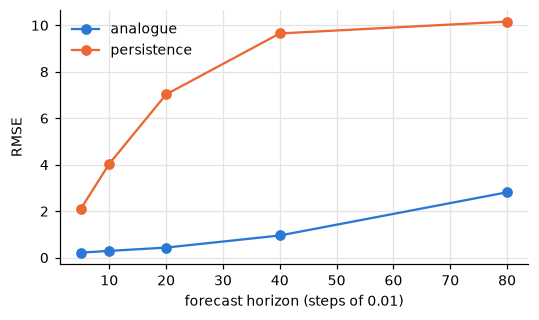

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.plot([r[0] for r in rows], [r[1] for r in rows], "o-", color=BLUE, label="analogue")
ax.plot([r[0] for r in rows], [r[2] for r in rows], "o-", color=ORANGE, label="persistence")
ax.set_xlabel("forecast horizon (steps of 0.01)"); ax.set_ylabel("RMSE"); ax.legend(frameon=False)
plt.show()

Analogues beat persistence by a wide margin at short horizons and the advantage shrinks as chaos
destroys predictability, which is Lorenz's original point. The same code, with a volatility
embedding instead of a delay embedding, is what the paper applies to financial risk.